# **About Dataset**

## **Context**
This dataset contains simulated patient analytics data. It provides a comprehensive view of patient demographics, hospital visits, treatments, and outcomes, making it suitable for practicing data manipulation, visualization, and predictive modeling in the healthcare domain.

## **Content**
The dataset contains records with the following columns:

patient_id: A unique identifier for each patient.  
visit_date: The date of the patient's visit to the healthcare facility.  
age_group: The age category of the patient (e.g., 18-30, 31-50, 51+).  
gender: The gender of the patient.  
region: The geographic region of the patient.  
department: The hospital department visited (e.g., Cardiology, General Practice).  
treatment_type: The type of treatment administered.  
visit_type: The nature of the visit (e.g., Inpatient, Outpatient, Emergency).  
length_of_stay_days: The total number of days the patient stayed in the hospital.  
treatment_cost: The total cost associated with the treatment.  
recovery_score: A score indicating the patient's recovery progress.  
readmission_risk: The assessed risk of the patient being readmitted (e.g., High, Low, Medium).  

## *Acknowledgements*
The dataset is a synthetic construct created to facilitate learning and practice in healthcare data analytics.

## **Inspiration**
* Which departments incur the highest average treatment costs?
* Is there a correlation between the length of stay and the recovery score?
* What factors most significantly contribute to a high readmission risk?
* How do treatment costs vary across different age groups and regions?
* Can we build a model to predict the readmission risk based on patient characteristics and visit details?

# **Data Cleaning**

 I cleaned my data by using SQL in BigQuery.

## **View Sample Rows**
 
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`   
LIMIT 10;

### **Columns Identified (data_type)**

patient_id (int)  
visit_date (timestamp)  
age_group (str)  
gender (str)  
region (str)  
department (str)  
treatment_type (str)  
visit_type (str)  
length_of_stay_days (float)  
treatment_cost (float)  
recovery_score (float)  
readmission_risk (float)  

## **Count Records**

SELECT COUNT (*)  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`   
* *5000 records*

### **Remove Duplicates**

SELECT DISTINCT patient_id  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`   
* *5000 records; no duplicates found*  

## **Find Missing Values**

SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`   
WHERE patient_id IS NULL;  
* *no null records found*  
    
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`   
WHERE visit_date IS NULL;  
* *no null records found*   
    
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
WHERE age_group IS NULL;  
* *no null records found*   
    
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
WHERE gender IS NULL;  
* *no null records found*   
    
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
WHERE region IS NULL;  
* *no null records found*  
    
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
WHERE department IS NULL;  
* *no null records found*  
    
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
WHERE treatment_type IS NULL;  
* *no null records found*  
    
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
WHERE visit_type IS NULL;  
* *no null records found*  
    
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
WHERE length_of_stay_days IS NULL;  
* *no null records found*  
    
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
WHERE treatment_cost IS NULL;  
* *no null records found*  
    
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
WHERE recovery_score IS NULL;  
* *no null records found*  
    
SELECT *  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
WHERE readmission_risk IS NULL;  
* *no null records found*  


## **Standardize Formatting**

SELECT DISTINCT age_group  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
* *no capitalization inconsistencies or extra spaces found*  

SELECT DISTINCT gender  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
* *no capitalization inconsistencies or extra spaces found* 
    
SELECT DISTINCT region  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
* *no capitalization inconsistencies or extra spaces found* 
    
SELECT DISTINCT department  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
* *no capitalization inconsistencies or extra spaces found* 
    
SELECT DISTINCT treatment_type  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
* *no capitalization inconsistencies or extra spaces found* 
    
SELECT DISTINCT visit_type  
FROM `healthcare-patient-analysis.healthcare_patient_analysis.healthcare_patient_analysis`  
* *no capitalization inconsistencies or extra spaces found* 

# **Data Analysis**

This is how I setup my environment in Python.

In [1]:
# Import needed packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import .csv file
df = pd.read_csv('/kaggle/input/datasets/kristinmbrown26/healthcare-patient-analysis-clean/healthcare_patient_analysis_clean.csv')

# Pull :5 rows to view the data
df.head()

,patient_id,visit_date,age_group,gender,region,department,treatment_type,visit_type,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
0,3442,2022-05-24 09:00:00 UTC,31-45,Male,South,Cardiology,Observation,Emergency,6.4,4313,88,0.01
1,4451,2022-07-05 10:00:00 UTC,31-45,Female,South,Cardiology,Observation,Emergency,2.7,56569,73,0.01
2,34,2022-01-02 09:00:00 UTC,60+,Female,South,Cardiology,Therapy,Routine,5.3,70235,96,0.02
3,2031,2022-03-26 14:00:00 UTC,18-30,Female,West,Cardiology,Therapy,Routine,4.6,27748,84,0.02
4,2211,2022-04-03 02:00:00 UTC,46-60,Male,West,Cardiology,Therapy,Routine,0.5,34847,100,0.02


In [2]:
# Find min, max, mean, std, and quartiles of the data
df.describe()

,patient_id,length_of_stay_days,treatment_cost,recovery_score,readmission_risk
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,4.059660,54915.471800,74.718800,0.280966
std,1443.520003,1.928847,19481.160487,11.870481,0.157178
min,1.000000,0.000000,746.000000,33.000000,0.010000
25%,1250.750000,2.700000,41244.750000,67.000000,0.160000
50%,2500.500000,4.000000,55123.500000,75.000000,0.260000
75%,3750.250000,5.400000,68012.000000,83.000000,0.380000
max,5000.000000,11.900000,119307.000000,100.000000,0.840000


***


## **Questions and Analysis**

### **Inspiration Question 1**
* Which departments incur the highest average treatment costs?

In [3]:
# Group by departments and find the average treatment cost
treatment_cost_by_department = df.groupby(['department'])[['treatment_cost']].mean(numeric_only=True)

# Display the treatment cost in descending order
treatment_cost_by_department.sort_values(by='treatment_cost', ascending=False)

,treatment_cost
department,
Neurology,55761.751810
Cardiology,55632.595980
Orthopedics,54912.558601
Pediatrics,54781.584429
General Medicine,53506.395560


#### **Inspiration Question 1 Conclusion**

The department with the highest average treatment cost is Neurology, followed closely by Cardiology, Orthopedics, and Pediatrics.  

The department with the lowest average treatment cost is General Medicine.



***

### **Inspiration Question 2**
* Is there a correlation between the length of stay and the recovery score?

In [4]:
#Compile mean data

# Group data
avg_rs_by_stay = (
    df.groupby('recovery_score')[['length_of_stay_days']]
      .mean()
      .reset_index()
)

# Create recovery score groups in increments of 5
avg_grouped_rs_by_stay = (avg_rs_by_stay.index / 5).round() * 5

# Calculate the average length of stay for each recovery score group
avg_grouped_rs_by_stay2 = (
    avg_rs_by_stay
    .groupby(avg_grouped_rs_by_stay)['length_of_stay_days']
    .mean()
    .reset_index()
    .sort_values(by='length_of_stay_days')
)

avg_grouped_rs_by_stay2

,index,length_of_stay_days
0,0.0,3.450000
1,5.0,3.726667
13,65.0,3.772374
7,35.0,3.936013
6,30.0,3.947088
4,20.0,4.015706
9,45.0,4.035252
10,50.0,4.055200
2,10.0,4.055303
5,25.0,4.060157


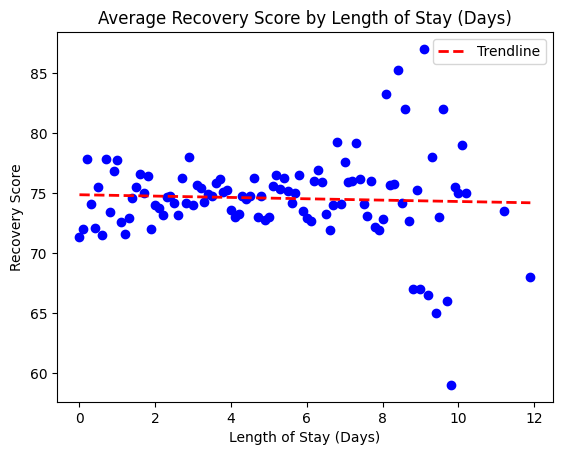

In [5]:
# Convert series to a dataframe
avg_rs_by_stay = (
    df.groupby('length_of_stay_days')['recovery_score']
      .mean()
      .reset_index()
)

# Define x and y
x = avg_rs_by_stay['length_of_stay_days']
y = avg_rs_by_stay['recovery_score']

# Scatterplot
plt.scatter(x, y, color="blue")

# Trendline
coefficients = np.polyfit(x, y, 1)
polynomial = np.poly1d(coefficients)
trendline_y = polynomial(x)

plt.plot(x, trendline_y, color='red', linestyle='--', linewidth=2, label='Trendline')

# Labels
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Recovery Score')
plt.title('Average Recovery Score by Length of Stay (Days)')
plt.legend()

plt.show()

In [6]:
# Ensure length_of_stay_days is a whole number
df['length_of_stay_days'] = df['length_of_stay_days'].round(0).astype(int)

# Group by whole days
grouped_length_of_stays = (
    df.groupby('length_of_stay_days', as_index=False)['recovery_score']
      .mean()
      .sort_values('length_of_stay_days')
)

grouped_length_of_stays

,length_of_stay_days,recovery_score
0,0,74.006757
1,1,74.358974
2,2,74.424419
3,3,75.075351
4,4,74.609206
5,5,74.761651
6,6,74.678042
7,7,75.662500
8,8,75.092025
9,9,72.368421


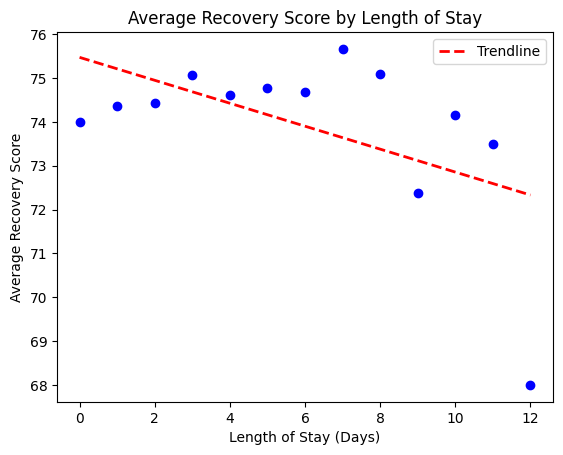

In [7]:
# Data
x = grouped_length_of_stays['length_of_stay_days']
y = grouped_length_of_stays['recovery_score']

# Scatterplot
plt.scatter(x, y, color="blue")

# Trendline
coefficients = np.polyfit(x, y, 1)
polynomial = np.poly1d(coefficients)
trendline_y = polynomial(x)

plt.plot(x, trendline_y, color='red', linestyle='--', linewidth=2, label='Trendline')

# Labels
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Average Recovery Score')
plt.title('Average Recovery Score by Length of Stay')
plt.legend()

plt.show()

#### **Inspiration Question 2 Conclusion**

There appears to be a slight trend for average length of stay by recovery score, with the lower recovery scores correlating to a longer stay.  

However, there is a strong trend for recovery score by length of stay, with longer stays correlating to a lower recovery score.

***

### **Inspiration Question 3**
* What factors most significantly contribute to a high readmission risk?


In [8]:
# Analyze how the readmission risk varies by each of the appropriate attributes provided

# Group by age group and find the average readmission rate
rr_by_age_group = (
    df.groupby('age_group', as_index=False)['readmission_risk']
      .mean()
)
rr_by_age_group

,age_group,readmission_risk
0,18-30,0.275425
1,31-45,0.282040
2,46-60,0.281920
3,60+,0.286521


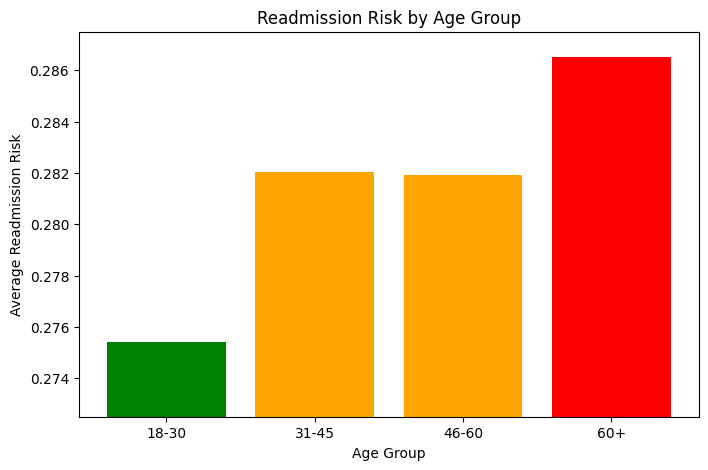

In [9]:
# Define colors based on age group
colors = []

for group in rr_by_age_group['age_group']:
    if group == '18-30':
        colors.append('green')
    elif group in ['31-45', '46-60']:
        colors.append('orange')
    elif group == '60+':
        colors.append('red')
    else:
        colors.append('gray')  # fallback in case new groups exist

plt.figure(figsize=(8,5))

plt.bar(
    rr_by_age_group['age_group'],
    rr_by_age_group['readmission_risk'],
    color=colors
)

plt.xlabel('Age Group')
plt.ylabel('Average Readmission Risk')
plt.title('Readmission Risk by Age Group')

# Zoom level
plt.ylim(0.2725, 0.2875)

plt.show()

In [10]:
# Calculate percentage increases for data

# Create a dictionary of age group -> average readmission risk
risk = rr_by_age_group.set_index('age_group')['readmission_risk']

# Calculate percent increases
print(f"60+ vs 18-30: {((risk['60+'] - risk['18-30']) / risk['18-30']) * 100:.2f}%")
print(f"60+ vs 31-45: {((risk['60+'] - risk['31-45']) / risk['31-45']) * 100:.2f}%")
print(f"60+ vs 46-60: {((risk['60+'] - risk['46-60']) / risk['46-60']) * 100:.2f}%")
print(f"46-60 vs 18-30: {((risk['46-60'] - risk['18-30']) / risk['18-30']) * 100:.2f}%")
print(f"46-60 vs 31-45: {((risk['46-60'] - risk['31-45']) / risk['31-45']) * 100:.2f}%")
print(f"31-45 vs 18-30: {((risk['31-45'] - risk['18-30']) / risk['18-30']) * 100:.2f}%")

60+ vs 18-30: 4.03%
60+ vs 31-45: 1.59%
60+ vs 46-60: 1.63%
46-60 vs 18-30: 2.36%
46-60 vs 31-45: -0.04%
31-45 vs 18-30: 2.40%


### Readmission Risk by Gender

In [11]:
# Group by gender and find the average readmission rate
rr_by_gender = (
    df.groupby('gender', as_index=False)[['readmission_risk']]
      .mean()
)

rr_by_gender

,gender,readmission_risk
0,Female,0.282259
1,Male,0.279681


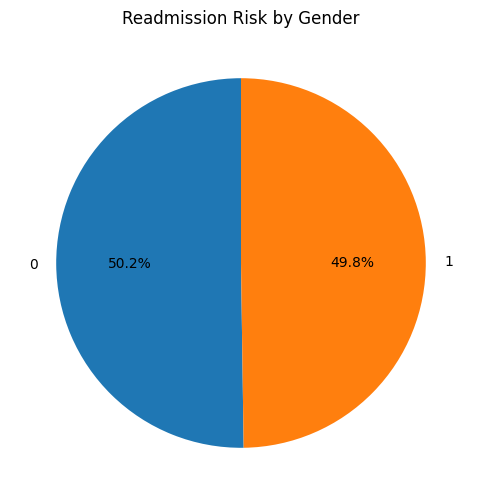

In [12]:
# Data
labels = rr_by_gender.index
values = rr_by_gender['readmission_risk']

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)

# Title
plt.title('Readmission Risk by Gender')

plt.show()

In [13]:
# Calculate percentage increases for data

# Create a dictionary of age group -> average readmission risk
risk = rr_by_gender.set_index('gender')['readmission_risk']

# Calculate percent increases
print(f"Female vs Male: {((risk['Female'] - risk['Male']) / risk['Male']) * 100:.2f}%")

Female vs Male: 0.92%


### Readmission Risk by Region

In [14]:
# Group by region and find the average readmission rate
rr_by_region = (
    df.groupby('region')[['readmission_risk']]
      .mean()
      .reset_index()
      .sort_values(by='readmission_risk', ascending=False)
)

rr_by_region

,region,readmission_risk
0,East,0.284363
2,South,0.282502
3,West,0.279054
1,North,0.278214


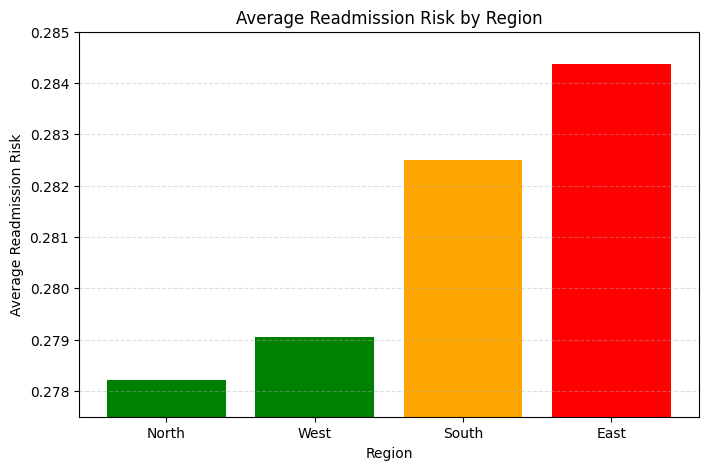

In [15]:
# Set the desired order
region_order = ['North', 'West', 'South', 'East']

rr_by_region['region'] = pd.Categorical(
    rr_by_region['region'],
    categories=region_order,
    ordered=True
)

rr_by_region = rr_by_region.sort_values('region')

# Assign colors
color_map = {
    'North': 'green',
    'West': 'green',
    'South': 'orange',
    'East': 'red'
}

colors = [color_map[region] for region in rr_by_region['region']]

# Plot
plt.figure(figsize=(8,5))

plt.bar(
    rr_by_region['region'],
    rr_by_region['readmission_risk'],
    color=colors
)

plt.xlabel('Region')
plt.ylabel('Average Readmission Risk')
plt.title('Average Readmission Risk by Region')

# Zoom in on the y-axis
plt.ylim(0.2775, 0.285)

# Add horizontal gridlines
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [16]:
# Create a Series
risk = rr_by_region.set_index('region')['readmission_risk']

# Calculate relative increases
comparisons = [
    ('East', 'North'),
    ('East', 'West'),
    ('East', 'South'),
    ('South', 'West'),
    ('South', 'North'),
    ('West', 'North')
]

print("Relative increase in average readmission risk:\n")

for higher, lower in comparisons:
    pct = ((risk[higher] - risk[lower]) / risk[lower]) * 100
    print(f"{higher} is {pct:.2f}% more likely to result in readmission than {lower}.")

Relative increase in average readmission risk:

East is 2.21% more likely to result in readmission than North.
East is 1.90% more likely to result in readmission than West.
East is 0.66% more likely to result in readmission than South.
South is 1.24% more likely to result in readmission than West.
South is 1.54% more likely to result in readmission than North.
West is 0.30% more likely to result in readmission than North.


### Readmission Risk by Department

In [17]:
# Group by department and find the average readmission rate
rr_by_department = (
    df.groupby('department', as_index=False)['readmission_risk']
      .mean()
      .reset_index()
      .sort_values(by='readmission_risk', ascending=False)
)
rr_by_department

,index,department,readmission_risk
2,2,Neurology,0.283744
4,4,Pediatrics,0.282305
1,1,General Medicine,0.281968
3,3,Orthopedics,0.278771
0,0,Cardiology,0.278271


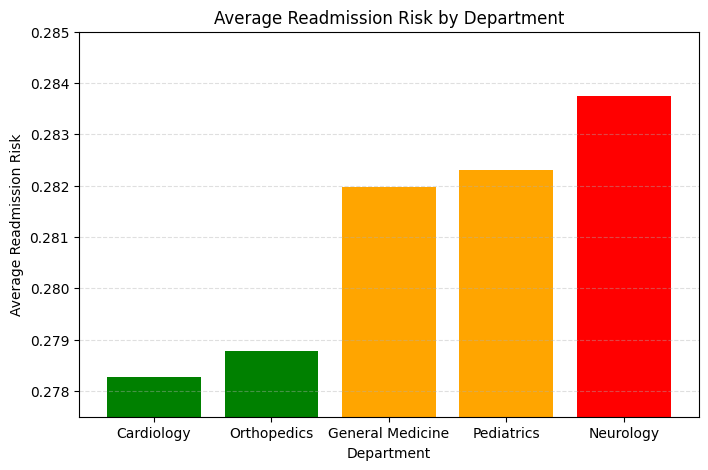

In [18]:
# Set order to display
department_order = [
    'Cardiology',
    'Orthopedics',
    'General Medicine',
    'Pediatrics',
    'Neurology'
]

rr_by_department['department'] = pd.Categorical(
    rr_by_department['department'],
    categories=department_order,
    ordered=True
)
rr_by_department = rr_by_department.sort_values('department')

# Set colors
color_map = {
    'Cardiology': 'green',
    'Orthopedics': 'green',
    'Pediatrics': 'orange',
    'Neurology': 'red',
    'General Medicine': 'orange'
}

colors = [color_map[d] for d in rr_by_department['department']]

# Bar chart
plt.figure(figsize=(8,5))

plt.bar(
    rr_by_department['department'],
    rr_by_department['readmission_risk'],
    color=colors
)

# Label
plt.xlabel('Department')
plt.ylabel('Average Readmission Risk')
plt.title('Average Readmission Risk by Department')

plt.ylim(0.2775, 0.285)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [19]:
# Create a Series
risk = rr_by_department.set_index('department')['readmission_risk']

# Calculate relative increases
comparisons = [
    ('Neurology', 'Pediatrics'),
    ('Neurology', 'General Medicine'),
    ('Neurology', 'Orthopedics'),
    ('Neurology', 'Cardiology'),
    ('Pediatrics', 'General Medicine'),
    ('Pediatrics', 'Orthopedics'),
    ('Pediatrics', 'Cardiology'),
    ('General Medicine', 'Orthopedics'),
    ('General Medicine', 'Cardiology'),
    ('Orthopedics', 'Cardiology')
]

print("Relative increase in average readmission risk:\n")

for higher, lower in comparisons:
    pct = ((risk[higher] - risk[lower]) / risk[lower]) * 100
    print(f"{higher} is {pct:.2f}% more likely to result in readmission than {lower}.")

Relative increase in average readmission risk:

Neurology is 0.51% more likely to result in readmission than Pediatrics.
Neurology is 0.63% more likely to result in readmission than General Medicine.
Neurology is 1.78% more likely to result in readmission than Orthopedics.
Neurology is 1.97% more likely to result in readmission than Cardiology.
Pediatrics is 0.12% more likely to result in readmission than General Medicine.
Pediatrics is 1.27% more likely to result in readmission than Orthopedics.
Pediatrics is 1.45% more likely to result in readmission than Cardiology.
General Medicine is 1.15% more likely to result in readmission than Orthopedics.
General Medicine is 1.33% more likely to result in readmission than Cardiology.
Orthopedics is 0.18% more likely to result in readmission than Cardiology.


### Readmission Risk by Treatment Type

In [20]:
# Group by treatment type and find the average readmission rate
rr_by_treatment_type = (
    df.groupby('treatment_type', as_index=False)['readmission_risk']
      .mean()
      .reset_index()
      .sort_values(by='readmission_risk', ascending=False)
)
rr_by_treatment_type

,index,treatment_type,readmission_risk
1,1,Observation,0.282598
3,3,Therapy,0.282597
2,2,Surgery,0.279746
0,0,Medication,0.278908


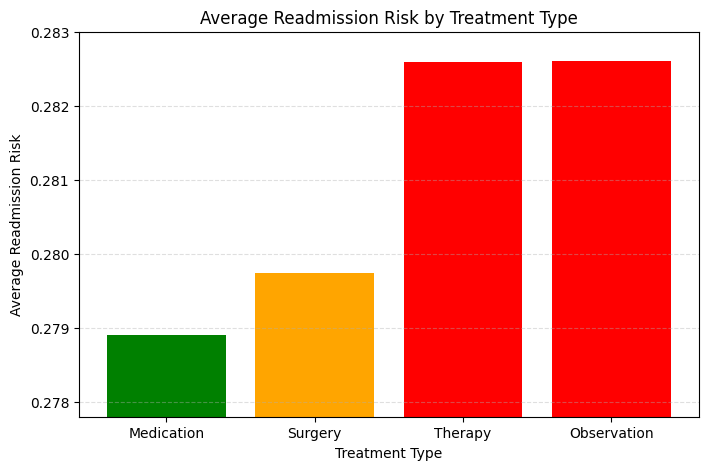

In [21]:
# Set Order
treatment_type_order = [
    'Medication',
    'Surgery',
    'Therapy',
    'Observation'
]
rr_by_treatment_type['treatment_type'] = pd.Categorical(
    rr_by_treatment_type['treatment_type'],
    categories=treatment_type_order,
    ordered=True
)

rr_by_treatment_type = rr_by_treatment_type.sort_values('treatment_type')

# Set Colors
color_map = {
    'Medication': 'green',
    'Surgery': 'orange',
    'Therapy': 'red',
    'Observation': 'red'
}

colors = [color_map[d] for d in rr_by_treatment_type['treatment_type']]

#Bar chart
plt.figure(figsize=(8,5))

plt.bar(
    rr_by_treatment_type['treatment_type'],
    rr_by_treatment_type['readmission_risk'],
    color=colors
)

# Label
plt.xlabel('Treatment Type')
plt.ylabel('Average Readmission Risk')
plt.title('Average Readmission Risk by Treatment Type')

plt.ylim(0.2778, 0.283)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [22]:
# Create a Series
risk = rr_by_treatment_type.set_index('treatment_type')['readmission_risk']

# Calculate relative increases
comparisons = [
    ('Surgery', 'Medication'),
    ('Therapy', 'Medication'),
    ('Observation', 'Medication'),
    ('Therapy', 'Surgery'),
    ('Observation', 'Surgery'),
    ('Observation', 'Therapy')
]

print("Relative increase in average readmission risk:\n")

for higher, lower in comparisons:
    pct = ((risk[higher] - risk[lower]) / risk[lower]) * 100
    print(f"{higher} is {pct:.2f}% more likely to result in readmission than {lower}.")

Relative increase in average readmission risk:

Surgery is 0.30% more likely to result in readmission than Medication.
Therapy is 1.32% more likely to result in readmission than Medication.
Observation is 1.32% more likely to result in readmission than Medication.
Therapy is 1.02% more likely to result in readmission than Surgery.
Observation is 1.02% more likely to result in readmission than Surgery.
Observation is 0.00% more likely to result in readmission than Therapy.


### Readmission Risk by Length of Stay

In [23]:
# Group recovery score by length of stay
rr_by_length_of_stay = (
    df.groupby('length_of_stay_days', as_index=False)['readmission_risk']
      .mean()
      .reset_index()
      .sort_values('length_of_stay_days')
)

rr_by_length_of_stay

,index,length_of_stay_days,readmission_risk
0,0,0,0.273243
1,1,1,0.293045
2,2,2,0.278517
3,3,3,0.276437
4,4,4,0.285686
5,5,5,0.274328
6,6,6,0.280742
7,7,7,0.294719
8,8,8,0.279755
9,9,9,0.234737


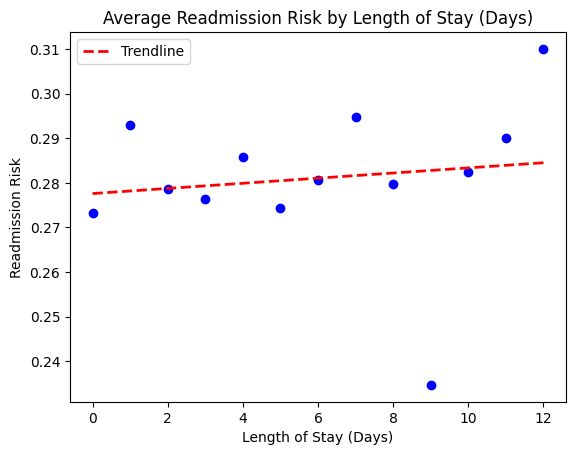

In [24]:
# Define x and y
x = rr_by_length_of_stay['length_of_stay_days']
y = rr_by_length_of_stay['readmission_risk']

# Scatterplot
plt.scatter(x, y, color="blue")

# Trendline
coefficients = np.polyfit(x, y, 1)
polynomial = np.poly1d(coefficients)
trendline_y = polynomial(x)

plt.plot(x, trendline_y, color='red', linestyle='--', linewidth=2, label='Trendline')

# Label
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Readmission Risk')
plt.title('Average Readmission Risk by Length of Stay (Days)')
plt.legend()

plt.show()

In [25]:
# Create a Series indexed by length of stay
risk = rr_by_length_of_stay.set_index('length_of_stay_days')['readmission_risk']

# Difference between 12 days and 0 days
dif = (
    rr_by_length_of_stay['readmission_risk'].iloc[12]
    - rr_by_length_of_stay['readmission_risk'].iloc[0]
)

print(f"The difference in average readmission risk between 12 days and 0 days is {dif:.4f}.")

# Relative increase
comparisons = [
    (12, 0),
]

for higher, lower in comparisons:
    pct = ((risk[higher] - risk[lower]) / risk[lower]) * 100
    print(f"{higher} days is {pct:.2f}% more likely to result in readmission than {lower} days.")

The difference in average readmission risk between 12 days and 0 days is 0.0368.
12 days is 13.45% more likely to result in readmission than 0 days.


### Readmission Risk by Treatment Cost

In [26]:
# Group readmission risk by treatment cost

rr_by_treatment_cost = (
    df.groupby('treatment_cost', as_index=False)['readmission_risk']
      .mean()
      .sort_values('treatment_cost')
)

# Create bins for the cost intervals
bin_edges = [0, 
             1000, 
             2000, 
             3000, 
             4000, 
             5000, 
             6000, 
             7000, 
             8000, 
             9000, 
             10000, 
             11000, 
             12000, 
             13000, 
             14000, 
             15000, 
             16000, 
             17000, 
             18000, 
             19000, 
             20000]
bin_labels = ['Under 1,000', 
              '1,000 - 1,999', 
              '2,000 - 2,999', 
              '3,000 - 3,999', 
              '4,000 - 4,999', 
              '5,000 - 5,999', 
              '6,000 - 6,999',
              '7,000 - 7,999',
              '8,000 - 8,999',
              '9,000 - 9,999',
              '10,000 - 10,999',
              '11,000 - 11,999',
              '12,000 - 12,999',
              '13,000 - 13,999',
              '14,000 - 14,999',
              '15,000 - 15,999',
              '16,000 - 16,999',
              '17,000 - 17,000',
              '18,000 - 18,999',
              '19,000 +']

# Create a dataframe using the bins and sort the data
df['cost_bin'] = pd.cut(
    df['treatment_cost'],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

rr_by_treatment_cost = (
    df.groupby('cost_bin', observed=True)['readmission_risk']
      .mean()
      .reset_index()
)

print(rr_by_treatment_cost)
rr_by_treatment_cost

           cost_bin  readmission_risk
0       Under 1,000          0.120000
1     1,000 - 1,999          0.218000
2     2,000 - 2,999          0.370000
3     3,000 - 3,999          0.380000
4     4,000 - 4,999          0.196000
5     5,000 - 5,999          0.305000
6     6,000 - 6,999          0.218571
7     7,000 - 7,999          0.263333
8     8,000 - 8,999          0.298333
9     9,000 - 9,999          0.378333
10  10,000 - 10,999          0.226667
11  11,000 - 11,999          0.288889
12  12,000 - 12,999          0.254286
13  13,000 - 13,999          0.358333
14  14,000 - 14,999          0.304545
15  15,000 - 15,999          0.295455
16  16,000 - 16,999          0.321250
17  17,000 - 17,000          0.236875
18  18,000 - 18,999          0.272941
19         19,000 +          0.254583


,cost_bin,readmission_risk
0,"Under 1,000",0.120000
1,"1,000 - 1,999",0.218000
2,"2,000 - 2,999",0.370000
3,"3,000 - 3,999",0.380000
4,"4,000 - 4,999",0.196000
5,"5,000 - 5,999",0.305000
6,"6,000 - 6,999",0.218571
7,"7,000 - 7,999",0.263333
8,"8,000 - 8,999",0.298333
9,"9,000 - 9,999",0.378333


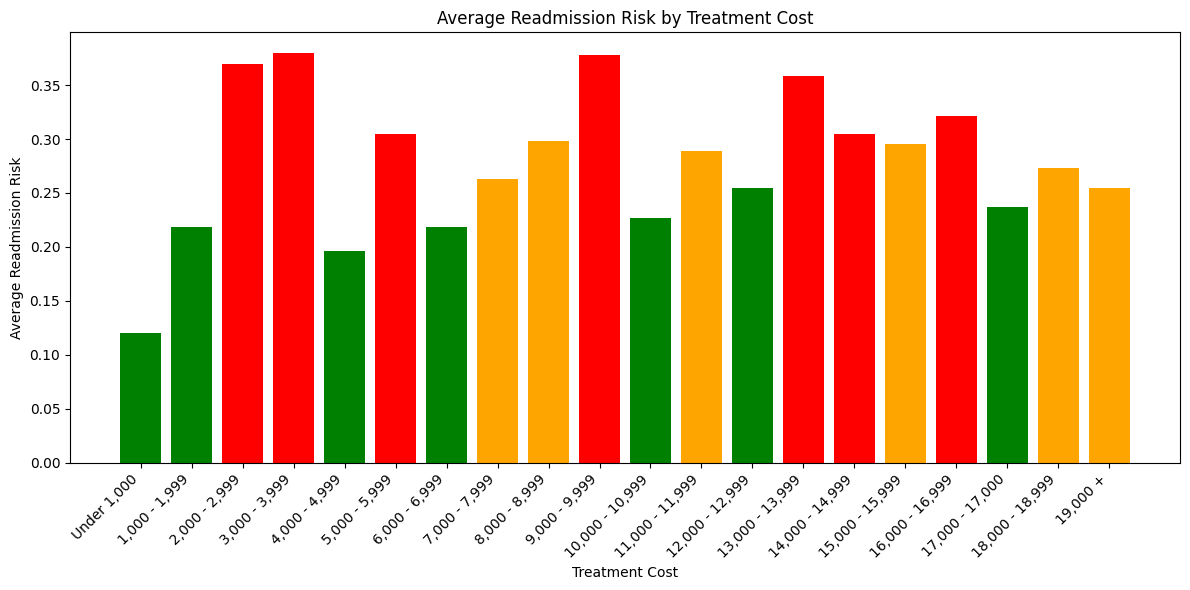

In [27]:
# Create color categories based on thirds of readmission risk
risk_groups = pd.qcut(
    rr_by_treatment_cost['readmission_risk'],
    q=3,
    labels=['green', 'orange', 'red']
)

# Bar chart
plt.figure(figsize=(12, 6))

plt.bar(
    rr_by_treatment_cost['cost_bin'].astype(str),
    rr_by_treatment_cost['readmission_risk'],
    color=risk_groups
)
    
# Label
plt.xlabel('Treatment Cost')
plt.ylabel('Average Readmission Risk')
plt.title('Average Readmission Risk by Treatment Cost')

# Rotate x-axis labels for readability
plt.xticks(rotation=45, ha='right')

# Adjust layout
plt.tight_layout()

plt.show()

### Readmission Risk by Recovery Score

In [28]:
# Group readmission risk by treatment cost

rr_by_recovery_score = (
    df.groupby('recovery_score', as_index=False)['readmission_risk']
      .mean()
      .reset_index()
      .sort_values('recovery_score')
)

# Create bins for the cost intervals
bin_edges = [0, 
             40, 
             50, 
             60, 
             70, 
             80, 
             90, 
             100]
bin_labels = ['Under 40',  
              '40 - 49', 
              '50 - 59', 
              '60 - 69',
              '70 - 79',
              '80 - 89',
              '90 - 100']

# Create a dataframe using the bins and sort the data
df['recovery_bin'] = pd.cut(
    df['recovery_score'],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

rr_by_recovery_score = (
    df.groupby('recovery_bin', observed=True)['readmission_risk']
      .mean()
      .reset_index()
)

print(rr_by_recovery_score)
rr_by_recovery_score

  recovery_bin  readmission_risk
0     Under 40          0.207692
1      40 - 49          0.321613
2      50 - 59          0.267131
3      60 - 69          0.281970
4      70 - 79          0.281859
5      80 - 89          0.280501
6     90 - 100          0.285064


,recovery_bin,readmission_risk
0,Under 40,0.207692
1,40 - 49,0.321613
2,50 - 59,0.267131
3,60 - 69,0.281970
4,70 - 79,0.281859
5,80 - 89,0.280501
6,90 - 100,0.285064


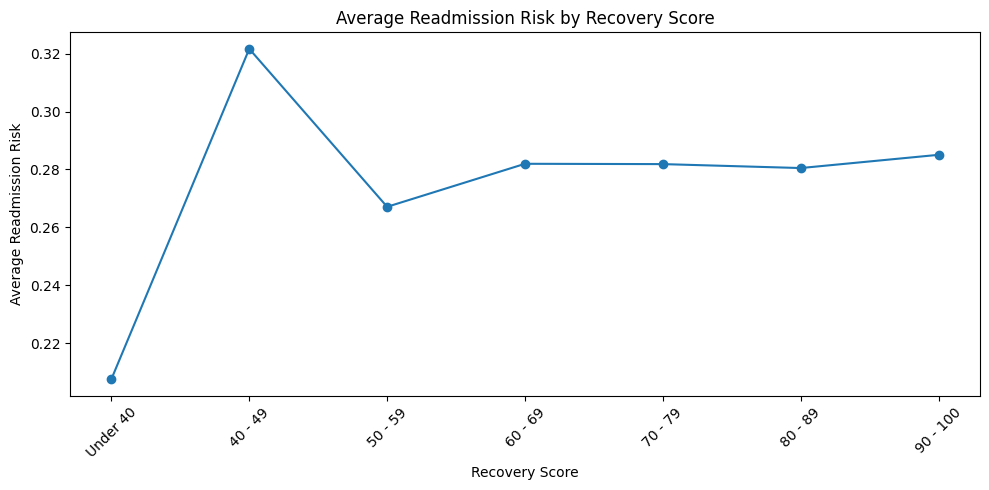

In [29]:
# Line chart
plt.figure(figsize=(10,5))

plt.plot(
    rr_by_recovery_score['recovery_bin'].astype(str),
    rr_by_recovery_score['readmission_risk'],
    marker='o'
)

plt.xlabel('Recovery Score')
plt.ylabel('Average Readmission Risk')
plt.title('Average Readmission Risk by Recovery Score')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Create a Series
risk = rr_by_recovery_score.set_index('recovery_bin')['readmission_risk']

# Calculate relative increases
comparisons = [
    ('90 - 100', '80 - 89'),
    ('90 - 100', '70 - 79'),
    ('90 - 100', '60 - 69'),
    ('90 - 100', '50 - 59'),
    ('90 - 100', '40 - 49'),
    ('90 - 100', 'Under 40'),
    ('80 - 89', '70 - 79'),
    ('80 - 89', '60 - 69'),
    ('80 - 89', '50 - 59'),
    ('80 - 89', '40 - 49'),
    ('80 - 89', 'Under 40'),
    ('70 - 79', '60 - 69'),
    ('70 - 79', '50 - 59'),
    ('70 - 79', '40 - 49'),
    ('70 - 79', 'Under 40'),
    ('60 - 69', '50 - 59'),
    ('60 - 69', '40 - 49'),
    ('60 - 69', 'Under 40'),
    ('50 - 59', '40 - 49'),
    ('50 - 59', 'Under 40'),
    ('40 - 49', 'Under 40')
]

print("Relative increase in average readmission risk:\n")

for higher, lower in comparisons:
    pct = ((risk[higher] - risk[lower]) / risk[lower]) * 100
    print(f"{higher} is {pct:.2f}% more likely to result in readmission than {lower}.")

Relative increase in average readmission risk:

90 - 100 is 1.63% more likely to result in readmission than 80 - 89.
90 - 100 is 1.14% more likely to result in readmission than 70 - 79.
90 - 100 is 1.10% more likely to result in readmission than 60 - 69.
90 - 100 is 6.71% more likely to result in readmission than 50 - 59.
90 - 100 is -11.36% more likely to result in readmission than 40 - 49.
90 - 100 is 37.25% more likely to result in readmission than Under 40.
80 - 89 is -0.48% more likely to result in readmission than 70 - 79.
80 - 89 is -0.52% more likely to result in readmission than 60 - 69.
80 - 89 is 5.00% more likely to result in readmission than 50 - 59.
80 - 89 is -12.78% more likely to result in readmission than 40 - 49.
80 - 89 is 35.06% more likely to result in readmission than Under 40.
70 - 79 is -0.04% more likely to result in readmission than 60 - 69.
70 - 79 is 5.51% more likely to result in readmission than 50 - 59.
70 - 79 is -12.36% more likely to result in readmis

### Readmission Risk by Region

In [31]:
# Group by region and find the average readmission rate
rr_by_region = (
    df.groupby('region')[['readmission_risk']]
      .mean()
      .reset_index()
      .sort_values(by='readmission_risk', ascending=False)
)

rr_by_region

,region,readmission_risk
0,East,0.284363
2,South,0.282502
3,West,0.279054
1,North,0.278214


### **Inspiration Question 3 Conclusion**

#### *Readmission Rate by Age Group*

The findings in the readmission rate by age group were very clear with the 18-30 age group having the lowest readmission rate of 0.275425.  

The 31-45 and 46-60 age groups were very close in average readmission rates with only a .04% difference between the two. Patients in the 31-45 age group were 2.4% more likely to be readmitted than those in the 18-30 age group, while patients in the 46-60 age group were 2.36% more likely to be readmitted than patients in the 18-30 age group.


The highest readmission rates were found in the 60+ age group.  Patients in this group saw a 1.63% higher readmission rate than 18-30 age group patients, a 1.59% higher rate than 31-45 patients, and 4.03% higher rate than patients aged 18-30.

#### *Readmission Rate by Gender*

After analyzing the readmission rates by gender, the data shows that gender has little effect on readmission rates.  Female patients hold a slighly higher readmission rate of .92% than males.

#### *Readmission Rate by Region*

Region is another attribute that seems to correlate with readmission rate.  The North region has the lowest readmission rate at 0.278214.  The West region comes closely after the North region with a 0.30% increase.  The South region has a slighlty higher readmission rate, with the readmission rate rising by 1.24% compared to the West region.  East has the highest correlation, being 0.66% higher than the South region and 2.21% higher than the lowest readmission rate of the North region.

#### *Readmission Rate by Department*

Department is also an attribute that has a slight yet direct correlation with readmission risk.  Cardiology carries the lowest readmission rate at 0.278271, followed closely by Orthopedics with only a 0.18% higher rate.  General Medicine and Pediatrics have a moderate readmission rate correlation with General Medicine being 1.15% higher than Orthopedics and Pediatrics is only higher than General Medicine 0.63%.  The highest readmission rate correlation is Neurology, which is 0.51% higher than Pediatrics and 1.97% higher than Cardiology.

#### *Readmission Rate by Treatment Type*

Treatment type is another key factor in readmission rate.  The lowest readmission rate lies with Medication, with just a 0.278908 readmission rate.  Surgery is a close second with only a 0.30% higher readmission rate.  Therapy and Observations have the highest average readmission rate. Therapy and Observation have a 1.32% higher readmission rate than Medication and a 1.02% higher readmission rate than Surgery.

#### *Readmission Rate by Length of Stay*

Length of stay shows the largest correlation for readmission rate. A length of stay of 12 days is 13.45% more likely to result in readmission than 0 days.

#### *Readmission Rate by Treatment Cost*

There appear to be no direct corrolations between readmission rate and treatment cost.

#### *Readmission Rate by Recovery Score*

There is an interesting correlation in readmission rate by recovery score.  The overall trend is having a recovery score of 60+ is a pretty stable readmission rate of 0.28.  There is a high spike at a recovery score of 40 - 49, and a very low spike at recovery scores under 40.  The difference between scores under 40 and scores of 40 - 49 is a 54.85% increase, where the increase of scores for scores under 40 to scores of 90 - 100 is 37.25%.

Investigating why under 40 scores had such a low readmission rate is recommended.

***

### **Inspiration Question 4**
* How do treatment costs vary across different age groups and regions?


In [32]:
# Analyze how the treatment cost varies by age group

# Group by age group and find the average readmission rate
tc_by_age_group = (
    df.groupby('age_group', as_index=False)['treatment_cost']
      .mean()
)
tc_by_age_group

,age_group,treatment_cost
0,18-30,55871.276695
1,31-45,54748.002914
2,46-60,54748.603462
3,60+,53919.812329


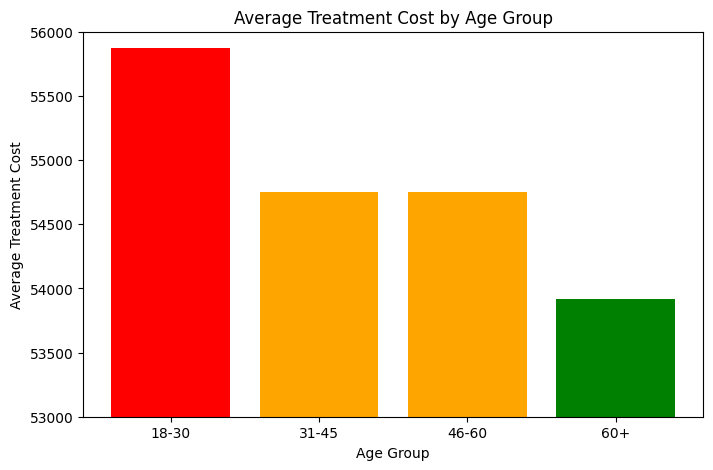

In [33]:
# Define colors based on age group
colors = []

for group in tc_by_age_group['age_group']:
    if group == '18-30':
        colors.append('red')
    elif group in ['31-45', '46-60']:
        colors.append('orange')
    elif group == '60+':
        colors.append('green')
    else:
        colors.append('gray')  # fallback in case new groups exist

plt.figure(figsize=(8,5))

plt.bar(
    tc_by_age_group['age_group'],
    tc_by_age_group['treatment_cost'],
    color=colors
)

plt.xlabel('Age Group')
plt.ylabel('Average Treatment Cost')
plt.title('Average Treatment Cost by Age Group')

# Zoom level
plt.ylim(53000, 56000)

plt.show()

In [34]:
# Calculate percentage increases for data

# Create a dictionary of age group -> average treatment cost
risk = tc_by_age_group.set_index('age_group')['treatment_cost']

# Calculate percent increases
print(f"18-30 vs 31-45: {((risk['18-30'] - risk['31-45']) / risk['31-45']) * 100:.2f}%")
print(f"18-30 vs 46-60: {((risk['18-30'] - risk['46-60']) / risk['46-60']) * 100:.2f}%")
print(f"18-30 vs 60+: {((risk['18-30'] - risk['60+']) / risk['60+']) * 100:.2f}%")
print(f"31-45 vs 46-60: {((risk['31-45'] - risk['46-60']) / risk['46-60']) * 100:.2f}%")
print(f"31-45 vs 60+: {((risk['31-45'] - risk['60+']) / risk['60+']) * 100:.2f}%")
print(f"46-60 vs 60+: {((risk['46-60'] - risk['60+']) / risk['60+']) * 100:.2f}%")

18-30 vs 31-45: 2.05%
18-30 vs 46-60: 2.05%
18-30 vs 60+: 3.62%
31-45 vs 46-60: -0.00%
31-45 vs 60+: 1.54%
46-60 vs 60+: 1.54%


In [35]:
# Group by region and find the average readmission rate
tc_by_region = (
    df.groupby('region')[['treatment_cost']]
      .mean()
      .reset_index()
      .sort_values(by='treatment_cost', ascending=False)
)

tc_by_region

,region,treatment_cost
2,South,55568.339389
1,North,55011.177067
3,West,54883.127907
0,East,54199.290058


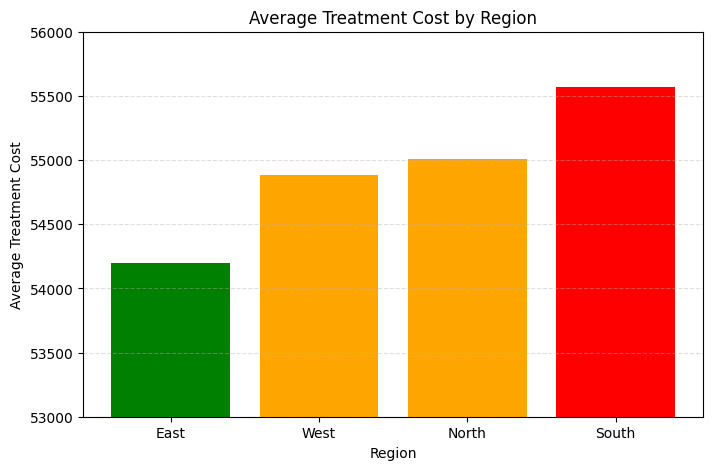

In [36]:
# Set the desired order
region_order = ['East', 'West', 'North', 'South']

tc_by_region['region'] = pd.Categorical(
    tc_by_region['region'],
    categories=region_order,
    ordered=True
)

tc_by_region = tc_by_region.sort_values('region')

# Assign colors
color_map = {
    'East': 'green',
    'West': 'orange',
    'North': 'orange',
    'South': 'red'
}

colors = [color_map[region] for region in tc_by_region['region']]

# Plot
plt.figure(figsize=(8,5))

plt.bar(
    tc_by_region['region'],
    tc_by_region['treatment_cost'],
    color=colors
)

plt.xlabel('Region')
plt.ylabel('Average Treatment Cost')
plt.title('Average Treatment Cost by Region')

# Zoom in on the y-axis
plt.ylim(53000, 56000)

# Add horizontal gridlines
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [37]:
# Create a Series
risk = tc_by_region.set_index('region')['treatment_cost']

# Calculate relative increases
comparisons = [
    ('South', 'North'),
    ('South', 'West'),
    ('South', 'East'),
    ('North', 'West'),
    ('North', 'East'),
    ('West', 'East')
]

print("Relative increase in average treatment cost:\n")

for higher, lower in comparisons:
    pct = ((risk[higher] - risk[lower]) / risk[lower]) * 100
    print(f"{higher} has a {pct:.2f}% higher treatment cost than {lower}.")

Relative increase in average treatment cost:

South has a 1.01% higher treatment cost than North.
South has a 1.25% higher treatment cost than West.
South has a 2.53% higher treatment cost than East.
North has a 0.23% higher treatment cost than West.
North has a 1.50% higher treatment cost than East.
West has a 1.26% higher treatment cost than East.


### **Inspiration Questin 4 Conclusion**

It appears that both age group and region have a correlation with treatment cost.  

### *Average Treatment Cost by Age Group*

Average treatment cost decreases as age increase, with patients in the 18 - 30 age group being 3.62% higher than those in the 60+ age group, and 2.05% higher than both the 31 - 45 and 46 - 60 age groups. 

### *Average Treatment Cost by Region*

The South region has the highest treatment cost, being 2.53% higher on average than the East region, 1.25% higher than the West, and 1.01% higher ethan the North region. The next highest treatment cost is the North region, which is 1.50% higher than the East region and 0.23% higher than the West region. The West region is 1.26% higher in average treatment cost, which is the lowest average treatment cost.

***

### **Inspiration Question 5**
* Can we build a model to predict the readmission risk based on patient characteristics and visit details?

In [38]:
# Select features
X = df[
[
    'age_group',
    'gender',
    'region',
    'department',
    'treatment_type',
    'visit_type',
    'length_of_stay_days',
    'treatment_cost',
    'recovery_score'
]]

y = df['readmission_risk']

In [39]:
# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

In [40]:
# Split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
# Train the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [42]:
# Make predicions
predictions = model.predict(X_test)

In [43]:
# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 0.1272
RMSE: 0.1557
R²: -0.0082


In [44]:
# Determine which features matter most with Linear Regression
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)

importance

,Feature,Coefficient
5,age_group_60+,1.281519e-02
4,age_group_46-60,1.033105e-02
3,age_group_31-45,9.616403e-03
14,treatment_type_Observation,5.155252e-03
10,department_General Medicine,4.610185e-03
16,treatment_type_Therapy,4.156540e-03
17,visit_type_Routine,1.387318e-03
15,treatment_type_Surgery,7.581040e-04
2,recovery_score,7.806374e-05
1,treatment_cost,1.966026e-07


In [45]:
# Sort coefficients by absolute magnatude
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance["Abs"] = importance["Coefficient"].abs()

importance = importance.sort_values("Abs", ascending=False)

importance.drop(columns="Abs")

,Feature,Coefficient
5,age_group_60+,1.281519e-02
4,age_group_46-60,1.033105e-02
3,age_group_31-45,9.616403e-03
7,region_North,-7.145424e-03
6,gender_Male,-5.577914e-03
14,treatment_type_Observation,5.155252e-03
10,department_General Medicine,4.610185e-03
12,department_Orthopedics,-4.337083e-03
13,department_Pediatrics,-4.246598e-03
16,treatment_type_Therapy,4.156540e-03


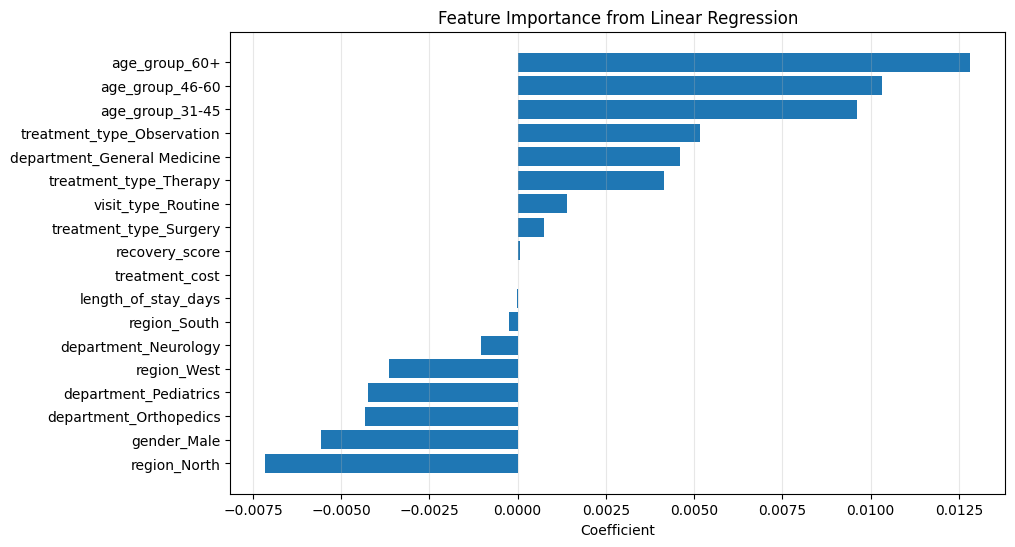

In [46]:
# Create a horizontal bar chart of the coefficients
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values("Coefficient")

plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Feature Importance from Linear Regression")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [48]:
# Create a Random Forest Regressor

#Import the model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [49]:
# Create the model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [51]:
# Make predictions
rf_predictions = rf_model.predict(X_test)

In [52]:
# Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_predictions)

print(f"MAE : {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²  : {rf_r2:.4f}")

MAE : 0.1300
RMSE: 0.1593
R²  : -0.0550


In [53]:
# Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
1,treatment_cost,0.328514
2,recovery_score,0.199134
0,length_of_stay_days,0.111508
17,visit_type_Routine,0.028757
3,age_group_31-45,0.026493
6,gender_Male,0.026349
15,treatment_type_Surgery,0.025539
8,region_South,0.025126
14,treatment_type_Observation,0.024820
16,treatment_type_Therapy,0.024601


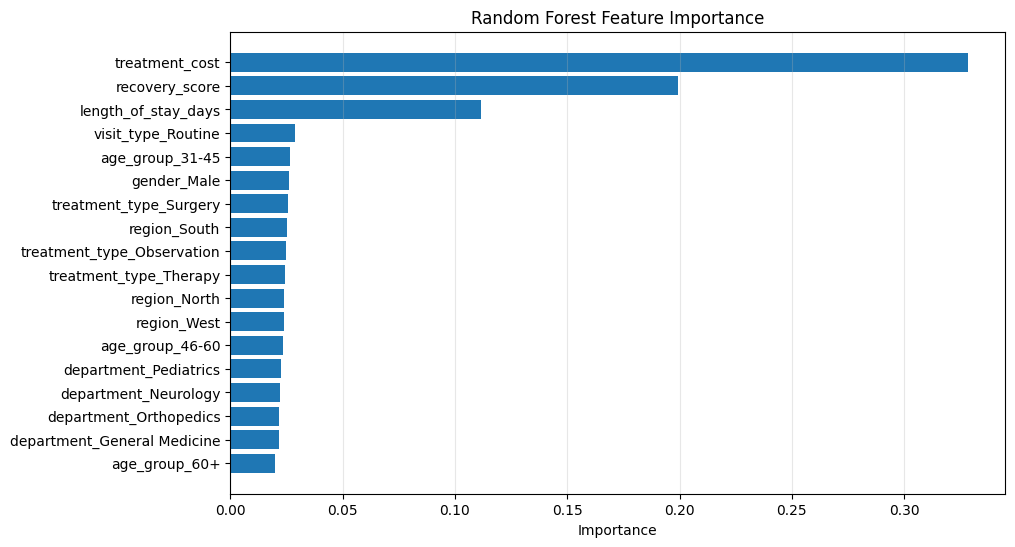

In [55]:
# Visualize
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=.3)

plt.show()

In [54]:
# Compare the models
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R²": [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,0.127212,0.155694,-0.008159
1,Random Forest,0.129975,0.159269,-0.054980


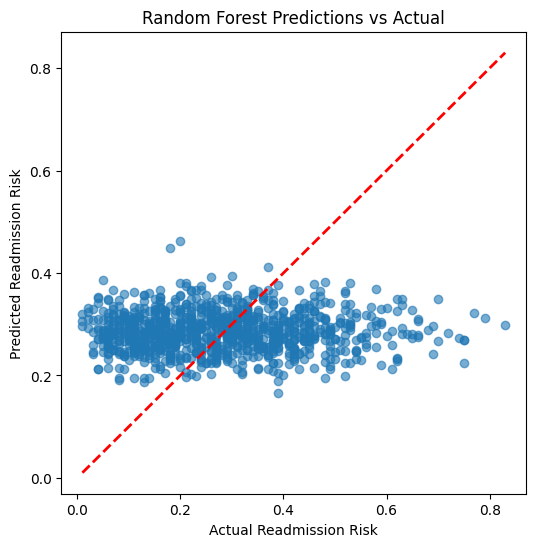

In [56]:
# Predicted v actual
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Readmission Risk")
plt.ylabel("Predicted Readmission Risk")
plt.title("Random Forest Predictions vs Actual")

plt.show()

### *Inspirationg Question 5 Conclusion*

A Linear Regression model and a Random Forest Regressor were developed to determine whether patient characteristics and visit details could predict readmission risk.

The Linear Regression model slightly outperformed the Random Forest model, but both produced negative R² values, indicating that neither model predicted readmission risk better than using the average readmission risk.

While the Linear Regression model identified age group, treatment type, and region as the strongest predictors, and the Random Forest emphasized treatment cost, recovery score, and length of stay, neither model demonstrated sufficient predictive accuracy. This suggests that the available variables do not contain enough predictive information to accurately model readmission risk within this synthetic dataset.

Overall, the results highlight the importance of evaluating predictive models and suggest that additional variables or a dataset with stronger underlying relationships would be needed to build a reliable readmission risk prediction model.

# *Overall Analysis Conclusion*

This analysis explored the relationships between patient demographics, hospital visit characteristics, treatment details, and patient outcomes using SQL for data cleaning and Python for data analysis, visualization, and predictive modeling.

The exploratory analysis found that age group, region, department, treatment type, and length of stay all showed varying levels of correlation with readmission risk. Patients aged 60 and older consistently demonstrated the highest average readmission risk, while longer hospital stays were associated with a greater likelihood of readmission. Treatment costs varied across both age groups and regions, with younger patients and those in the South region incurring the highest average treatment costs. Little to no meaningful relationship was found between treatment cost and readmission risk.

Predictive modeling was used to determine whether patient characteristics and visit details could accurately predict readmission risk. Although the Linear Regression model performed slightly better than the Random Forest model, neither model demonstrated sufficient predictive accuracy. This suggests that the available variables do not contain enough predictive information to reliably predict readmission risk within this synthetic dataset.

Overall, the analysis identified several meaningful patterns in patient outcomes while demonstrating the importance of validating findings through predictive modeling. Additional patient information or a dataset with stronger underlying relationships would likely be needed to develop a reliable model for predicting hospital readmission risk.